<a href="https://colab.research.google.com/github/Bhuvi8994/Job-Acceptance-Analytics/blob/main/job_acceptance_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/HR_Job_Placement_Dataset.csv')

In [ ]:
print(df.describe())

          age_years  ssc_percentage  hsc_percentage  degree_percentage  \
count  51500.000000    48919.000000    49435.000000       51500.000000   
mean      27.505456       70.002505       72.060636          74.010825   
std        4.025385        7.976314        7.916654           6.945579   
min       21.000000       50.000000       50.000000          55.000000   
25%       24.000000       64.574733       66.720058          69.305041   
50%       27.000000       69.971210       72.014383          73.998187   
75%       31.000000       75.389057       77.389894          78.707827   
max       34.000000       95.000000       95.000000          95.000000   

       technical_score  aptitude_score  communication_score  \
count     51500.000000    51500.000000         51500.000000   
mean         68.027499       64.005715            66.106692   
std          11.855145        9.922397             9.907488   
min          40.000000       40.000000            45.000000   
25%          59.93

In [ ]:
print("shape:", df.shape)

shape: (51500, 26)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: gender
gender
Female    24379
Male      24028
male       1549
female     1544
Name: count, dtype: int64


Column: degree_specialization
degree_specialization
Others                    10463
Electronics               10358
Information Technology    10298
Computer Science          10210
Mechanical                10171
Name: count, dtype: int64


Column: internship_experience
internship_experience
No      25607
Yes     23327
 no      1341
yes      1225
Name: count, dtype: int64


Column: career_switch_willingness
career_switch_willingness
Not Willing    28479
Willing        14555
Name: count, dtype: int64


Column: relevant_experience
relevant_experience
Relevant        26305
Not Relevant    16769
Name: count, dtype: int64


Column: company_tier
company_tier
Tier 1     19046
Tier 2     18301
Tier 3     12061
Tier 1       832
Tier 2       755
Tier 3       505
Name: count, dtype: int64


Column: job_role_match
job_role_match
Matched        33456
Not Matched    11913
Name: count, dty

In [ ]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [ ]:
df.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,2581
hsc_percentage,2065
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [ ]:
null_percent = df.isnull().mean() * 100
print(null_percent.sort_values(ascending=False))

relocation_willingness       16.456311
layoff_history               16.440777
career_switch_willingness    16.438835
relevant_experience          16.361165
job_role_match               11.904854
ssc_percentage                5.011650
hsc_percentage                4.009709
notice_period_days            3.071845
employment_gap_months         2.130097
gender                        0.000000
skills_match_percentage       0.000000
communication_score           0.000000
aptitude_score                0.000000
technical_score               0.000000
degree_specialization         0.000000
degree_percentage             0.000000
age_years                     0.000000
internship_experience         0.000000
company_tier                  0.000000
expected_ctc_lpa              0.000000
previous_ctc_lpa              0.000000
years_of_experience           0.000000
certifications_count          0.000000
competition_level             0.000000
bond_requirement              0.000000
status                   

In [ ]:
import numpy as np

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status'],
      dtype='object')

In [ ]:
df['gender'] = df['gender'].str.lower()
df['internship_experience'] = df['internship_experience'].str.lower()

In [ ]:
df.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,0
hsc_percentage,0
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

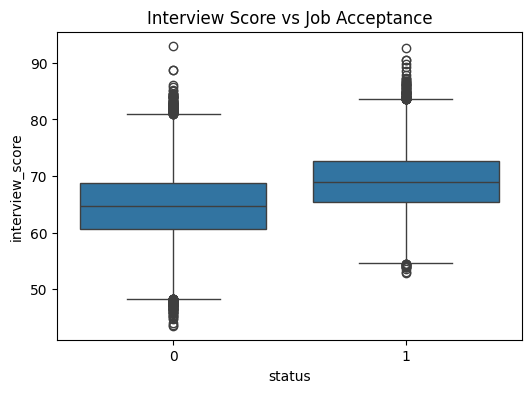

In [ ]:
df["interview_score"] = (
    df["technical_score"] +
    df["aptitude_score"] +
    df["communication_score"]
) / 3

plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="interview_score",
    data=df
)

plt.title("Interview Score vs Job Acceptance")
plt.show()

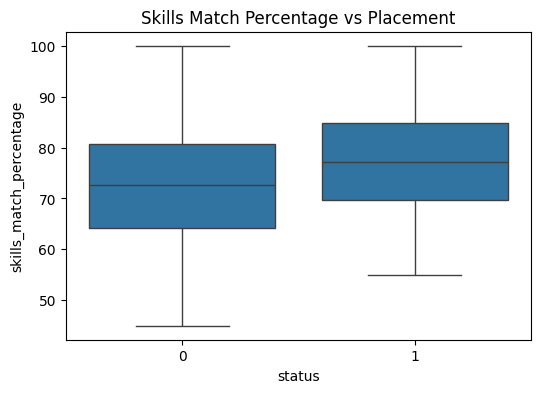

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="skills_match_percentage",
    data=df
)

plt.title("Skills Match Percentage vs Placement")

plt.show()


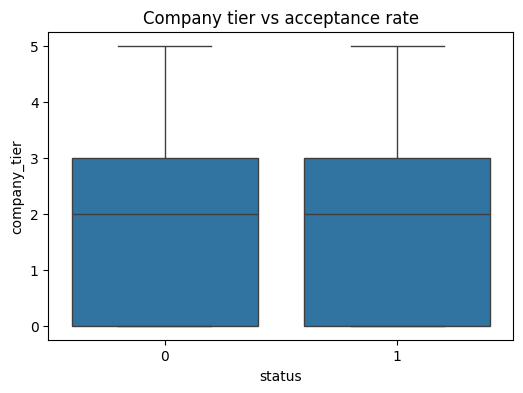

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="company_tier",
    data=df
)

plt.title("Company tier vs acceptance rate")
plt.show()

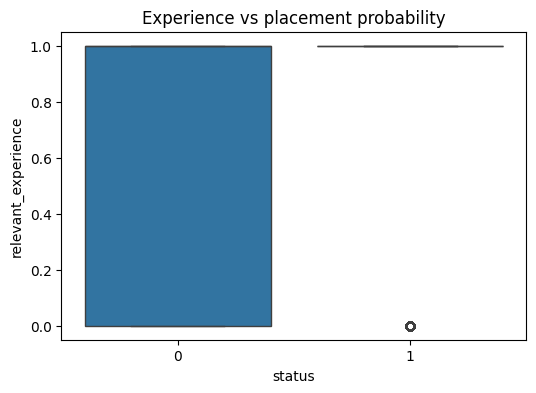

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="relevant_experience",
    data=df
)

plt.title("Experience vs placement probability")
plt.show()

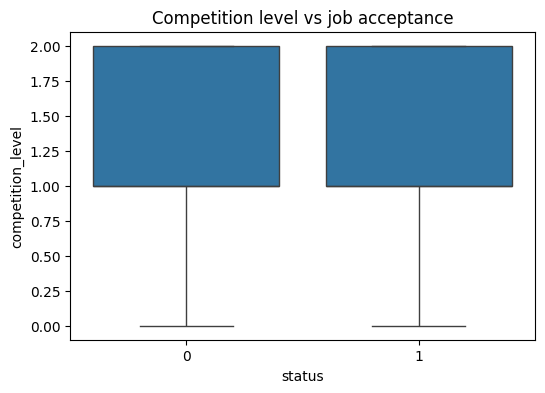

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="competition_level",
    data=df
)

plt.title("Competition level vs job acceptance")
plt.show()

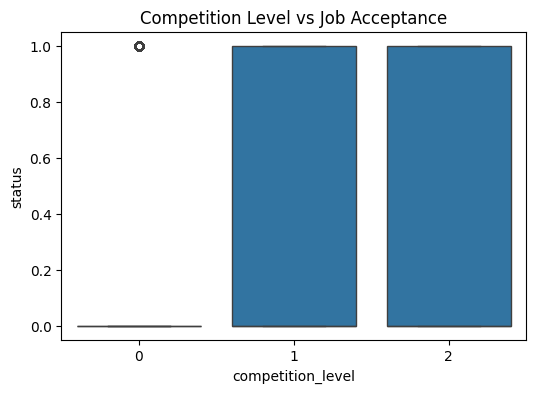

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="competition_level",
    y="status",
    data=df
)

plt.title("Competition Level vs Job Acceptance")

plt.show()

In [ ]:
def experience_category(x):
    if x == 0:
        return "Fresher"
    elif x <= 3:
        return "Junior"
    else:
        return "Senior"

df["experience_category"] = df["years_of_experience"].apply(experience_category)


In [ ]:
df["academic_score"] = (
    df["ssc_percentage"] +
    df["hsc_percentage"] +
    df["degree_percentage"])

def academic_band(x):
    if x < 60:
        return "Low"
    elif x < 75:
        return "Medium"
    else:
        return "High"

df["academic_band"] = df["academic_score"].apply(academic_band)

In [ ]:
def skills_level(x):
    if x < 50:
        return "Low"
    elif x < 75:
        return "Medium"
    else:
        return "High"

df["skills_level"] = df["skills_match_percentage"].apply(skills_level)

In [ ]:
df["interview_score"] = (
    df["technical_score"] +
    df["aptitude_score"] +
    df["communication_score"])

def interview_performance(x):
    if x < 60:
        return "Poor"
    elif x < 75:
        return "Average"
    else:
        return "Excellent"

df["interview_performance"] = df["interview_score"].apply(interview_performance)

In [ ]:
df["placement_probability"] = (
    0.4 * df["skills_match_percentage"] +
    0.3 * df["interview_score"] +
    0.3 * df["academic_score"])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
    "experience_category",
    "academic_band",
    "skills_level",
    "interview_performance"
]

for col in cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("status", axis=1)
y = df["status"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8444887780548629
Confusion Matrix:
[[6386  647]
 [ 912 2080]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      7033
           1       0.76      0.70      0.73      2992

    accuracy                           0.84     10025
   macro avg       0.82      0.80      0.81     10025
weighted avg       0.84      0.84      0.84     10025



In [ ]:
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df["academic_score"] = (
    df["ssc_percentage"] +
    df["hsc_percentage"] +
    df["degree_percentage"]
)

In [ ]:
df["interview_score"] = (
    df["technical_score"] +
    df["aptitude_score"] +
    df["communication_score"]
)

In [ ]:
df["placement_probability"] = (
    0.4 * df["skills_match_percentage"] +
    0.3 * df["interview_score"] +
    0.3 * df["academic_score"]
)

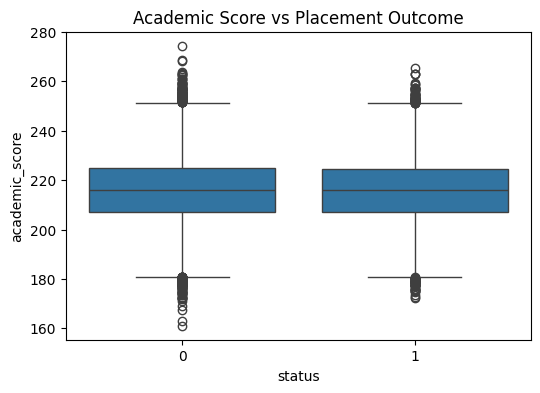

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="academic_score",
    data=df
)

plt.title("Academic Score vs Placement Outcome")

plt.show()

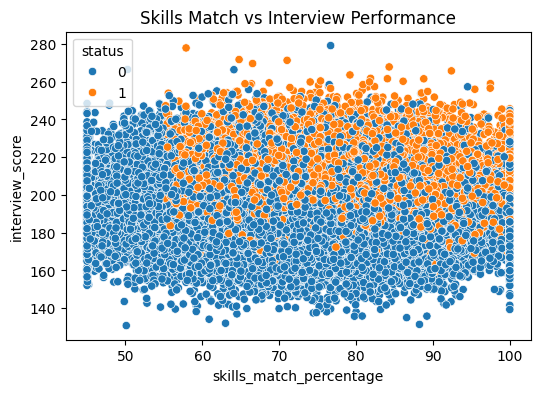

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="skills_match_percentage",
    y="interview_score",
    hue="status",
    data=df
)

plt.title("Skills Match vs Interview Performance")

plt.show()

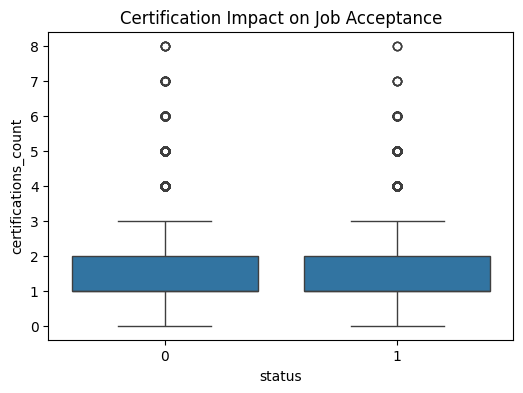

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="certifications_count",
    data=df
)

plt.title("Certification Impact on Job Acceptance")

plt.show()

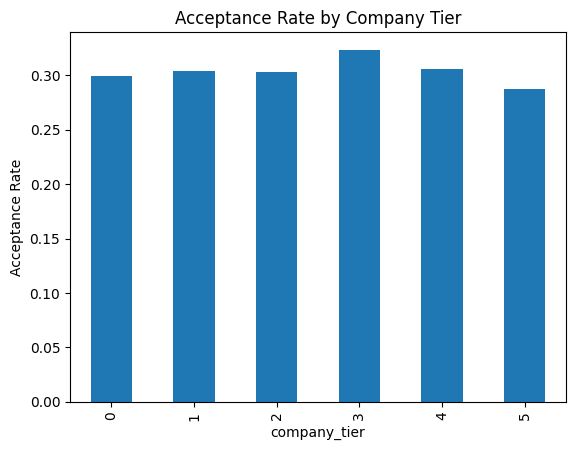

In [ ]:
company_acceptance = df.groupby("company_tier")["status"].mean()

company_acceptance.plot(kind="bar")

plt.title("Acceptance Rate by Company Tier")

plt.ylabel("Acceptance Rate")

plt.show()

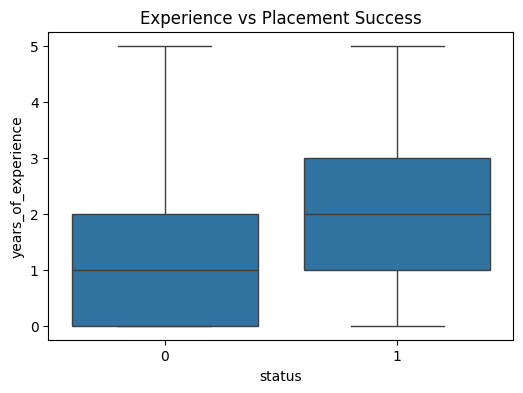

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="status",
    y="years_of_experience",
    data=df
)

plt.title("Experience vs Placement Success")

plt.show()

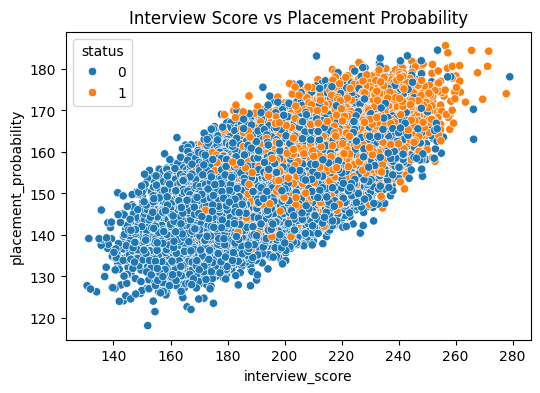

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="interview_score",
    y="placement_probability",
    hue="status",
    data=df
)

plt.title("Interview Score vs Placement Probability")

plt.show()

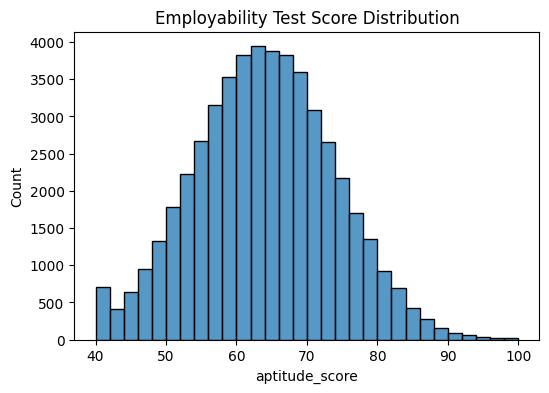

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(
    df["aptitude_score"],
    bins=30
)

plt.title("Employability Test Score Distribution")

plt.show()